#**Данные**


#1. Визуализация

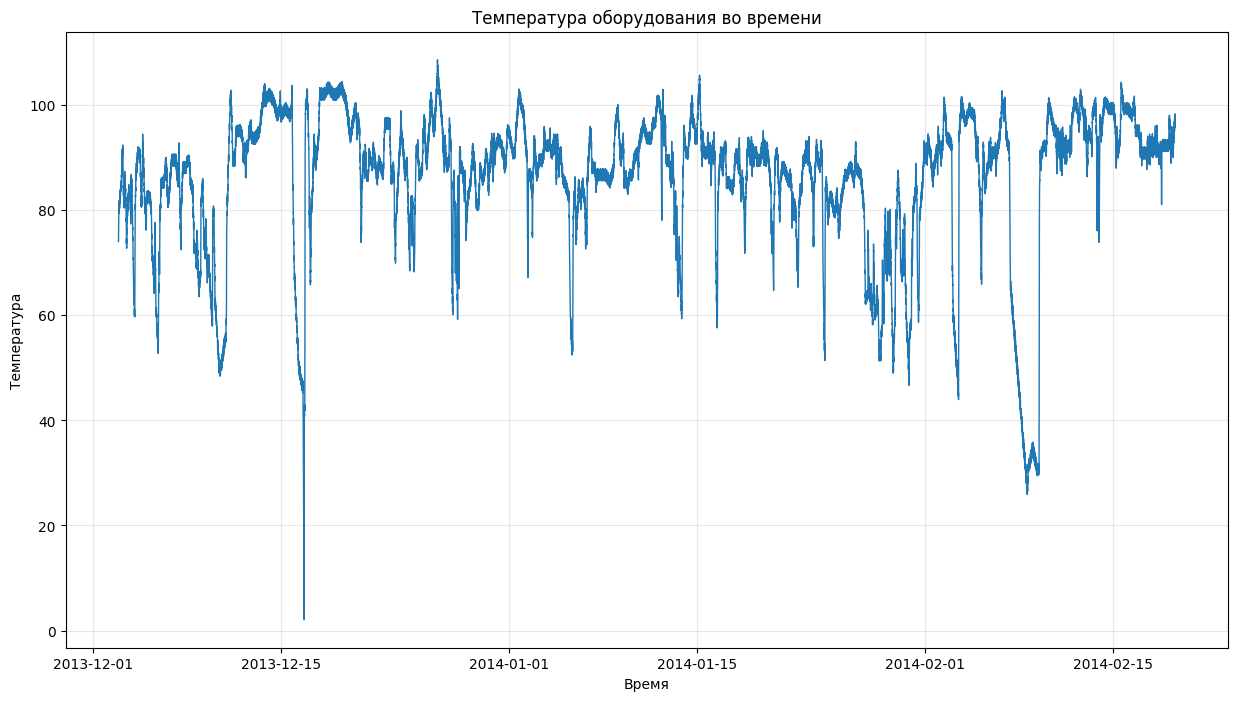

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('machine_temperature_system_failure.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

# Визуализация всего ряда
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['value'], linewidth=1)
plt.title('Температура оборудования во времени')
plt.xlabel('Время')
plt.ylabel('Температура')
plt.grid(True, alpha=0.3)
plt.show()

#2. Анализ компонентов и стационарности

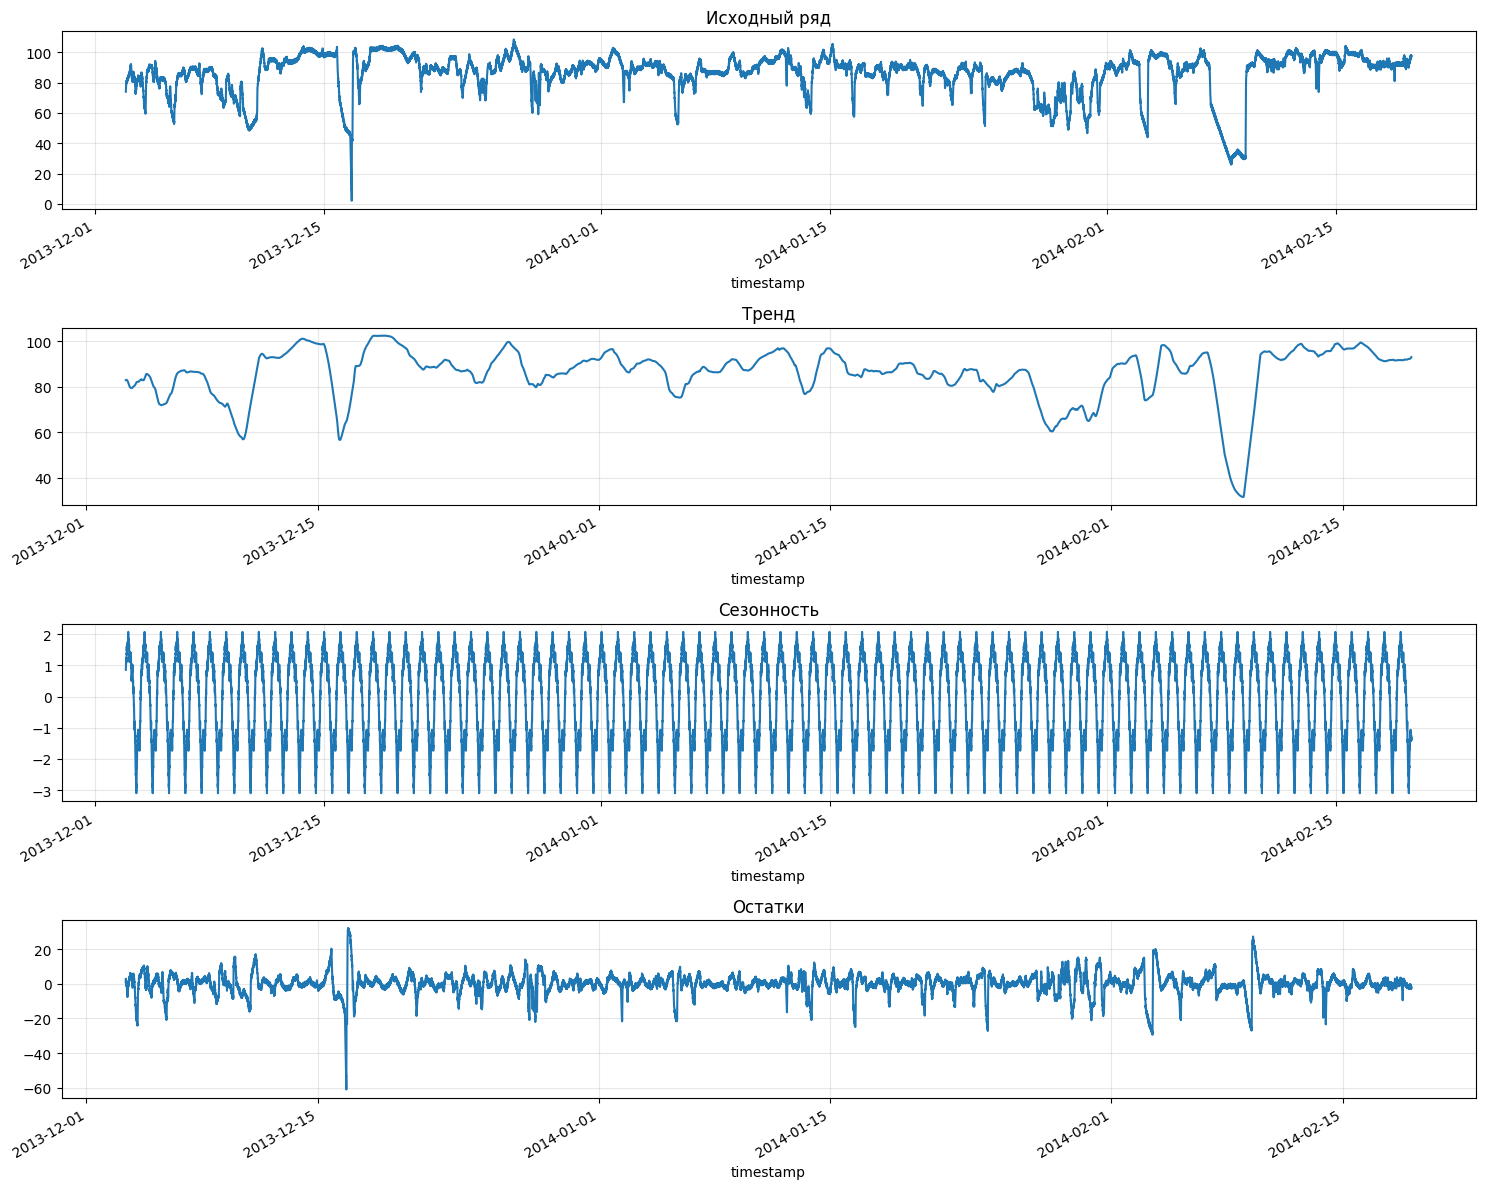

Тест на стационарность исходного ряда:
ADF Statistic: -7.369090
p-value: 0.000000
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567
Ряд стационарен (отвергаем H0)


In [12]:
# Декомпозиция временного ряда (возьмем суточную сезонность)
# Поскольку данные собраны с интервалом 5 минут, в сутках 288 наблюдений(60*24=1440 мин в сутках ,1440/5=288)
try:
    decomposition = seasonal_decompose(df['value'].dropna(), period=288, model='additive')

    fig, axes = plt.subplots(4, 1, figsize=(15, 12))

    decomposition.observed.plot(ax=axes[0], title='Исходный ряд')
    decomposition.trend.plot(ax=axes[1], title='Тренд')
    decomposition.seasonal.plot(ax=axes[2], title='Сезонность')
    decomposition.resid.plot(ax=axes[3], title='Остатки')

    for ax in axes:
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except:
    print("Не удалось выполнить декомпозицию с периодом 288, попробуем меньший период")

    # Попробуем часовую сезонность (12 наблюдений в часе)
    try:
        decomposition = seasonal_decompose(df['value'].dropna(), period=12, model='additive')

        fig, axes = plt.subplots(4, 1, figsize=(15, 12))

        decomposition.observed.plot(ax=axes[0], title='Исходный ряд')
        decomposition.trend.plot(ax=axes[1], title='Тренд')
        decomposition.seasonal.plot(ax=axes[2], title='Сезонность')
        decomposition.resid.plot(ax=axes[3], title='Остатки')

        for ax in axes:
            ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    except:
        print("Декомпозиция не удалась из-за пропусков в данных")

# Тест на стационарность (Дики-Фуллер)
def check_stationarity(timeseries):
    result = adfuller(timeseries.dropna())
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')

    if result[1] <= 0.05:
        print("Ряд стационарен (отвергаем H0)")
    else:
        print("Ряд нестационарен (не можем отвергнуть H0)")

print("Тест на стационарность исходного ряда:")
check_stationarity(df['value'])

#3. Train/Test Split

Размер обучающей выборки: 18156
Размер тестовой выборки: 4539
Дата разделения: 2014-02-03 21:10:00


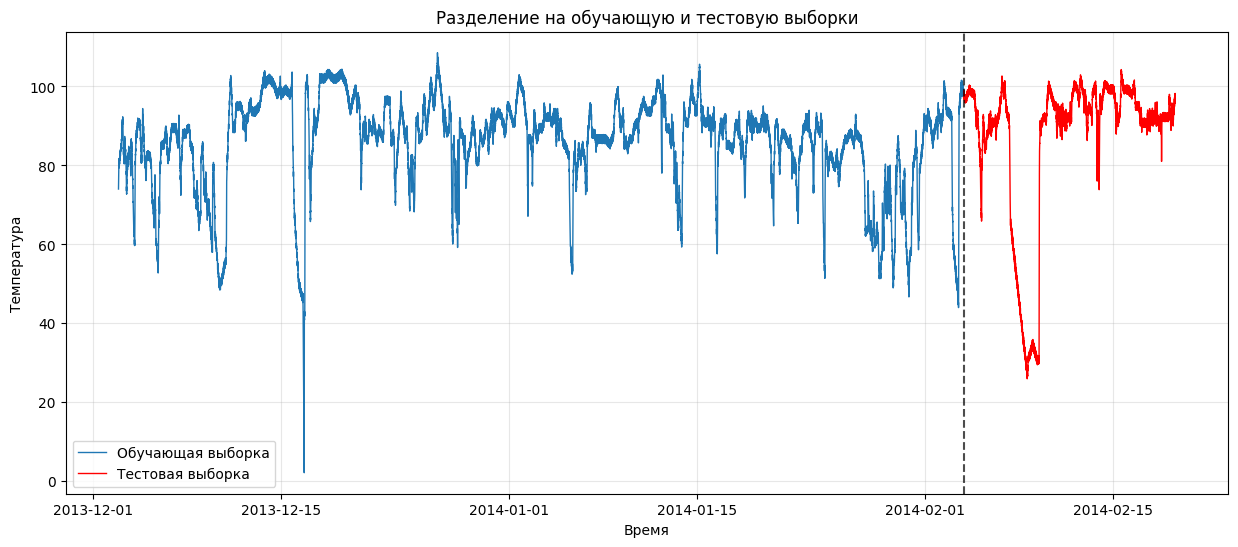

In [13]:
# Разделение на обучающую и тестовую выборки (80/20)
split_ratio = 0.8
split_point = int(len(df) * split_ratio)

train = df.iloc[:split_point]
test = df.iloc[split_point:]

print(f"Размер обучающей выборки: {len(train)}")
print(f"Размер тестовой выборки: {len(test)}")
print(f"Дата разделения: {train.index[-1]}")

# Визуализация разделения
plt.figure(figsize=(15, 6))
plt.plot(train.index, train['value'], label='Обучающая выборка', linewidth=1)
plt.plot(test.index, test['value'], label='Тестовая выборка', linewidth=1, color='red')
plt.axvline(x=train.index[-1], color='black', linestyle='--', alpha=0.7)
plt.title('Разделение на обучающую и тестовую выборки')
plt.xlabel('Время')
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#4. Выбор метрики качества

In [14]:
# Для задач прогнозирования температуры оборудования наиболее релевантными метриками являются:

metrics_info = {
    'MAE (Mean Absolute Error)': 'Средняя абсолютная ошибка - интерпретируемая метрика, показывает среднее отклонение в градусах',
    'RMSE (Root Mean Square Error)': 'Корень из средней квадратичной ошибки - более чувствительна к выбросам',
    'MAPE (Mean Absolute Percentage Error)': 'Средняя абсолютная процентная ошибка - относительная метрика',
    'sMAPE (Symmetric MAPE)': 'Симметричная MAPE - лучше работает при значениях близких к нулю'
}

print("Рекомендуемые метрики для оценки качества прогноза:")
for metric, description in metrics_info.items():
    print(f"• {metric}: {description}")

# Основной выбор - MAE, так как она легко интерпретируется
print("\nОсновная метрика: MAE (Mean Absolute Error)")
print("Дополнительные метрики: RMSE, MAPE")

Рекомендуемые метрики для оценки качества прогноза:
• MAE (Mean Absolute Error): Средняя абсолютная ошибка - интерпретируемая метрика, показывает среднее отклонение в градусах
• RMSE (Root Mean Square Error): Корень из средней квадратичной ошибки - более чувствительна к выбросам
• MAPE (Mean Absolute Percentage Error): Средняя абсолютная процентная ошибка - относительная метрика
• sMAPE (Symmetric MAPE): Симметричная MAPE - лучше работает при значениях близких к нулю

Основная метрика: MAE (Mean Absolute Error)
Дополнительные метрики: RMSE, MAPE


#**Прогнозирование**

#1.Бейзлайн модели

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Загрузка и подготовка данных
df = pd.read_csv('machine_temperature_system_failure.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

# Train/test split
split_ratio = 0.8
split_point = int(len(df) * split_ratio)
train = df.iloc[:split_point]
test = df.iloc[split_point:]

print(f"Train size: {len(train)}, Test size: {len(test)}")

# Функции для вычисления метрик
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape
    }

# Создаем датафрейм для хранения результатов
results_df = pd.DataFrame(columns=['Model', 'MAE', 'RMSE', 'MAPE'])

Train size: 18156, Test size: 4539


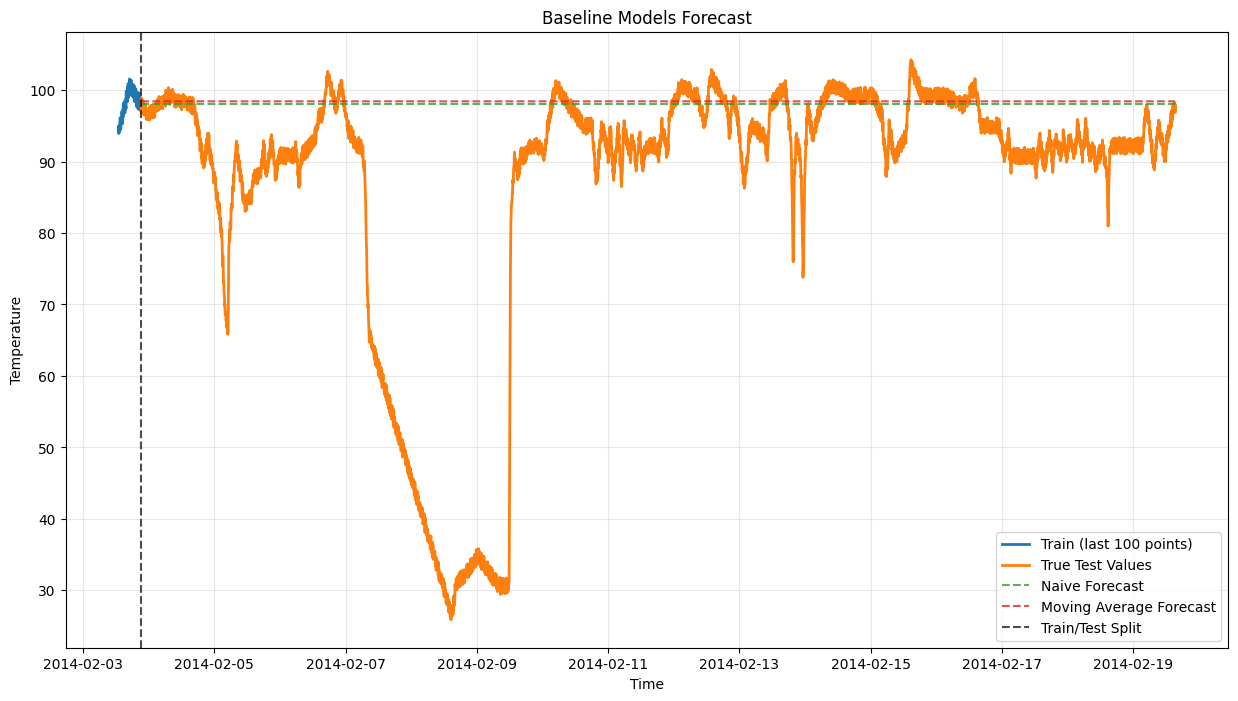

Baseline Models Results:
Naive Forecast - MAE: 12.0013, RMSE: 22.4795, MAPE: 26.38%
Moving Average - MAE: 12.2124, RMSE: 22.6687, MAPE: 26.70%


In [16]:
# Наивный прогноз (последнее известное значение)
naive_forecast = np.full(len(test), train['value'].iloc[-1])

# Скользящее среднее (используем среднее за последние 24 наблюдения - 2 часа)
window_size = 24
last_window_mean = train['value'].iloc[-window_size:].mean()
moving_avg_forecast = np.full(len(test), last_window_mean)

# Вычисляем метрики для бейзлайнов
naive_metrics = calculate_metrics(test['value'], naive_forecast, 'Naive Forecast')
moving_avg_metrics = calculate_metrics(test['value'], moving_avg_forecast, 'Moving Average')

# Добавляем в результаты
results_df = pd.concat([results_df, pd.DataFrame([naive_metrics, moving_avg_metrics])], ignore_index=True)

# Визуализация бейзлайнов
plt.figure(figsize=(15, 8))
plt.plot(train.index[-100:], train['value'].iloc[-100:], label='Train (last 100 points)', linewidth=2)
plt.plot(test.index, test['value'], label='True Test Values', linewidth=2)
plt.plot(test.index, naive_forecast, label='Naive Forecast', linestyle='--', alpha=0.8)
plt.plot(test.index, moving_avg_forecast, label='Moving Average Forecast', linestyle='--', alpha=0.8)
plt.axvline(x=train.index[-1], color='black', linestyle='--', alpha=0.7, label='Train/Test Split')
plt.title('Baseline Models Forecast')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Baseline Models Results:")
print(f"Naive Forecast - MAE: {naive_metrics['MAE']:.4f}, RMSE: {naive_metrics['RMSE']:.4f}, MAPE: {naive_metrics['MAPE']:.2f}%")
print(f"Moving Average - MAE: {moving_avg_metrics['MAE']:.4f}, RMSE: {moving_avg_metrics['RMSE']:.4f}, MAPE: {moving_avg_metrics['MAPE']:.2f}%")

#2. Статистическая модель (ARIMA/SARIMA)

Тест Дики-Фуллера для исходного ряда:
ADF Statistic: -7.835696
p-value: 0.000000
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567
→ Ряд стационарен (отвергаем H0)


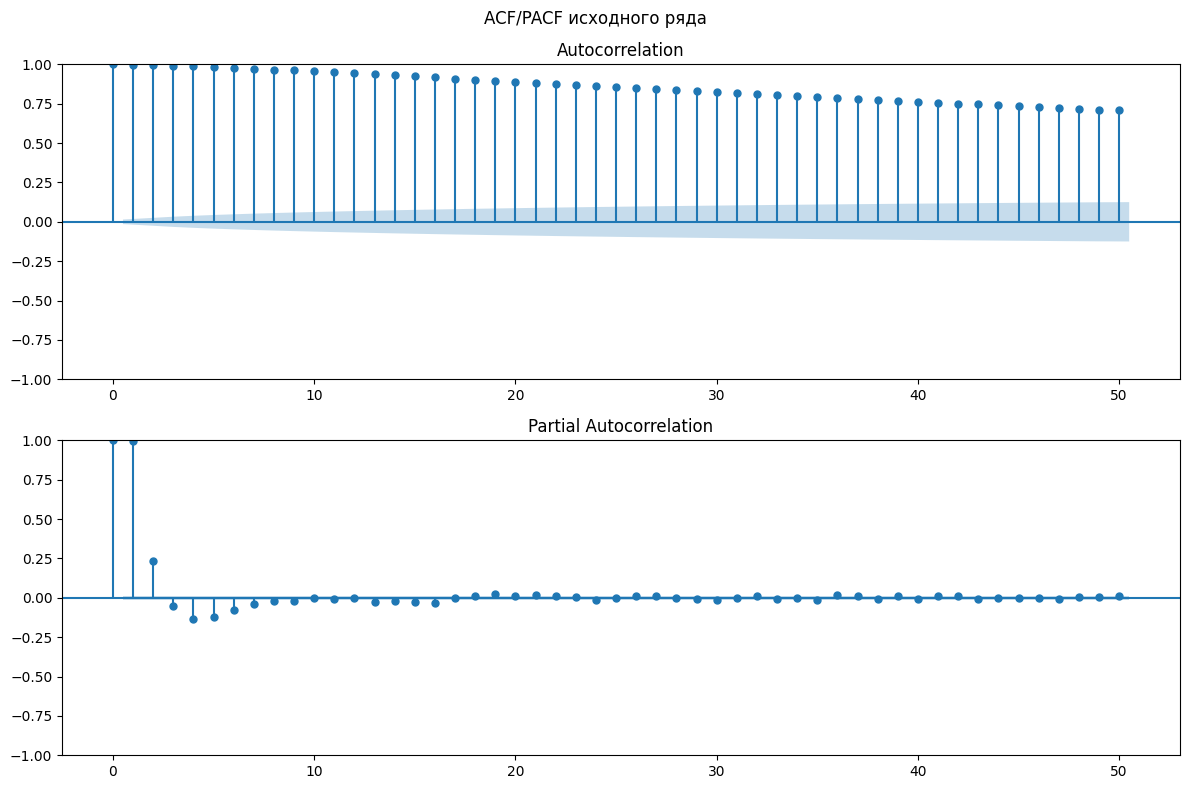

In [17]:
# Тест Дики-Фуллера для проверки стационарности
def adf_test(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')

    if result[1] <= 0.05:
        print("→ Ряд стационарен (отвергаем H0)")
    else:
        print("→ Ряд нестационарен (не можем отвергнуть H0)")
    return result[1]

print("Тест Дики-Фуллера для исходного ряда:")
p_value_original = adf_test(train['value'])

# ACF/PACF анализ
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train['value'].dropna(), ax=axes[0], lags=50)
plot_pacf(train['value'].dropna(), ax=axes[1], lags=50)
plt.suptitle('ACF/PACF исходного ряда')
plt.tight_layout()
plt.show()


После первого дифференцирования:
ADF Statistic: -27.018065
p-value: 0.000000
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567
→ Ряд стационарен (отвергаем H0)


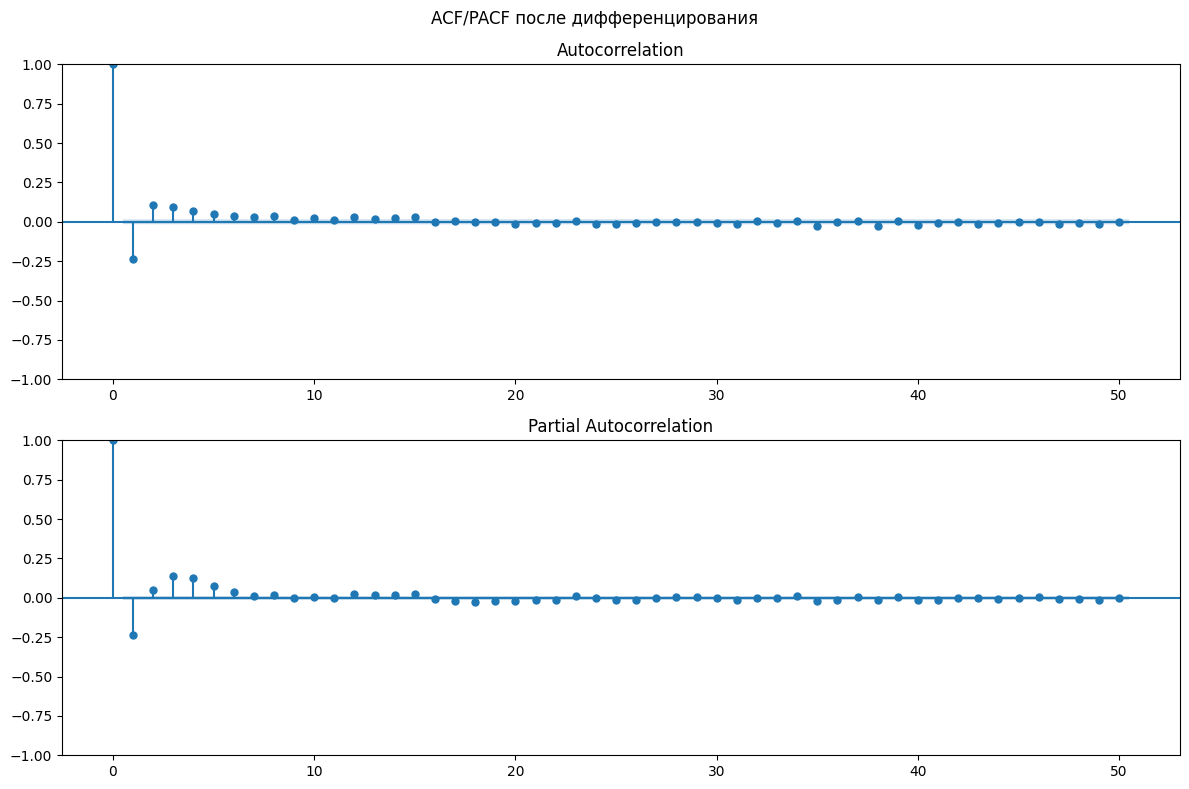

In [18]:
# Преобразования для стационарности
# 1. Первое дифференцирование
train_diff = train['value'].diff().dropna()

print("\nПосле первого дифференцирования:")
p_value_diff = adf_test(train_diff)

# ACF/PACF после дифференцирования
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train_diff, ax=axes[0], lags=50)
plot_pacf(train_diff, ax=axes[1], lags=50)
plt.suptitle('ACF/PACF после дифференцирования')
plt.tight_layout()
plt.show()

In [19]:
# Построение ARIMA модели
print("\nПодбор параметров ARIMA...")

# Попробуем несколько комбинаций параметров
arima_models = {}
best_arima = None
best_aic = np.inf

# Простые комбинации параметров
param_combinations = [(1,1,1), (1,1,0), (2,1,2), (0,1,1)]

for params in param_combinations:
    try:
        model = ARIMA(train['value'], order=params)
        fitted_model = model.fit()
        arima_models[params] = fitted_model
        if fitted_model.aic < best_aic:
            best_aic = fitted_model.aic
            best_arima = fitted_model
            best_params = params
        print(f"ARIMA{params} - AIC: {fitted_model.aic:.2f}")
    except Exception as e:
        print(f"ARIMA{params} - Error: {e}")

print(f"\nЛучшая модель: ARIMA{best_params} с AIC: {best_aic:.2f}")

# Прогноз ARIMA
arima_forecast = best_arima.forecast(steps=len(test))



Подбор параметров ARIMA...
ARIMA(1, 1, 1) - AIC: 53382.48
ARIMA(1, 1, 0) - AIC: 53403.74
ARIMA(2, 1, 2) - AIC: 52588.08
ARIMA(0, 1, 1) - AIC: 53585.15

Лучшая модель: ARIMA(2, 1, 2) с AIC: 52588.08


Попытка обучения SARIMA модели...
Автоматически определен период сезонности: 1
Обучение SARIMA с периодом 1...
 SARIMA модель не удалось обучить: Seasonal periodicity must be greater than 1.
Пробуем альтернативные подходы...
Попытка с простой сезонной моделью...
 Простая сезонная модель обучена


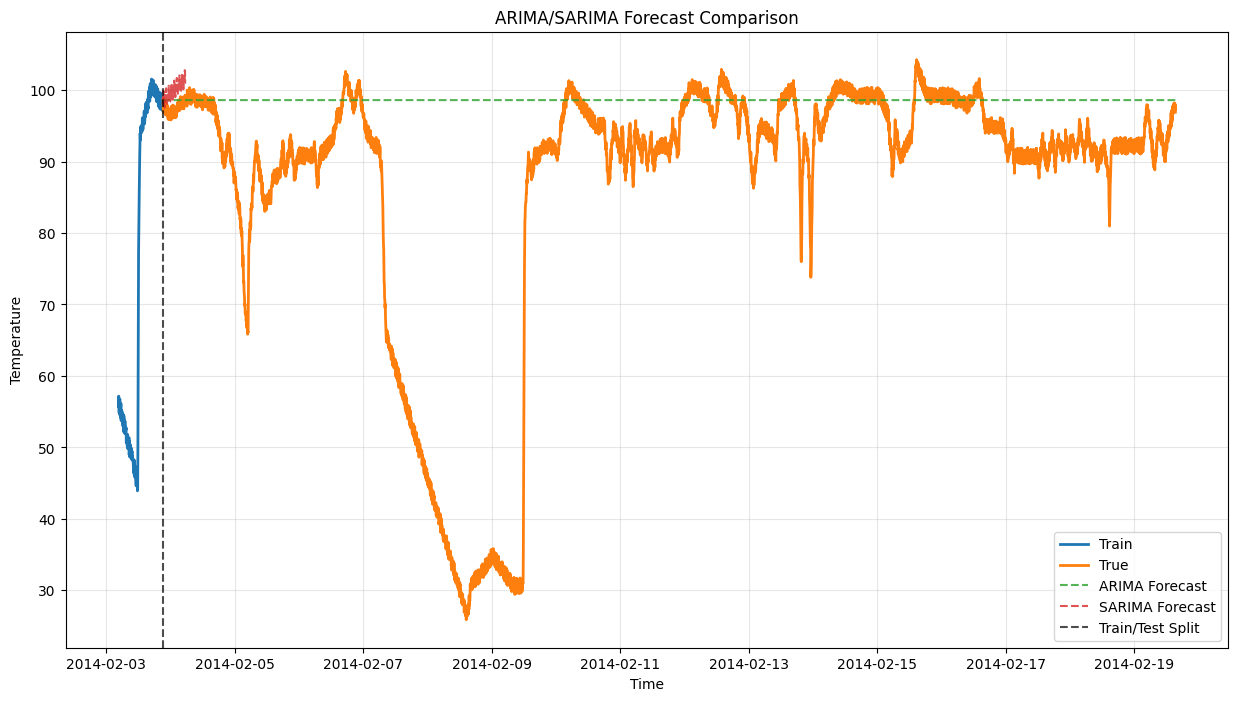


Статус обучения моделей:
 ARIMA: обучена успешно
 SARIMA: обучена успешно (прогноз на 100 шагов)


In [20]:
# SARIMA модель (с сезонностью) - ОПТИМИЗИРОВАННАЯ ВЕРСИЯ
try:
    print("Попытка обучения SARIMA модели...")

    # Вместо суточной сезонности (288) используем часовую (12 наблюдений)
    # или другую подходящую периодичность, которая есть в данных
    seasonal_period = 12  # 1 час (12 наблюдений по 5 минут)

    # Или определим период автоматически через ACF
    from statsmodels.tsa.stattools import acf

    # Анализ ACF для определения сезонности
    acf_values = acf(train['value'].dropna(), nlags=100)
    # Ищем значимые лаги
    significant_lags = np.where(np.abs(acf_values) > 1.96/np.sqrt(len(train)))[0]
    if len(significant_lags) > 1:
        # Берем первый значимый лаг как потенциальный период
        auto_seasonal_period = significant_lags[1] if significant_lags[1] > 0 else 12
        seasonal_period = min(auto_seasonal_period, 24)  # ограничиваем разумным размером
        print(f"Автоматически определен период сезонности: {seasonal_period}")
    else:
        seasonal_period = 12
        print(f"Используем период по умолчанию: {seasonal_period}")

    # Упрощенная SARIMA с меньшим количеством параметров
    print(f"Обучение SARIMA с периодом {seasonal_period}...")

    sarima_model = SARIMAX(train['value'],
                          order=(1,1,1),
                          seasonal_order=(0,1,1, seasonal_period),  # упрощаем сезонную часть
                          enforce_stationarity=False,
                          enforce_invertibility=False,
                          simple_differencing=True)  # ускоряет вычисления

    # Используем ограниченное число итераций
    sarima_fitted = sarima_model.fit(disp=False, maxiter=50)

    sarima_forecast = sarima_fitted.forecast(steps=min(len(test), 100))  # прогнозируем только часть

    print(" SARIMA модель обучена успешно")

    # Выравниваем размеры для сравнения
    test_for_sarima = test['value'].iloc[:len(sarima_forecast)]
    sarima_metrics = calculate_metrics(test_for_sarima, sarima_forecast, 'SARIMA')
    results_df = pd.concat([results_df, pd.DataFrame([sarima_metrics])], ignore_index=True)

except Exception as e:
    print(f" SARIMA модель не удалось обучить: {e}")
    print("Пробуем альтернативные подходы...")

    # Альтернатива 1: Простая сезонная модель
    try:
        print("Попытка с простой сезонной моделью...")
        # Используем сезонное дифференцирование + ARIMA
        seasonal_diff = train['value'].diff(periods=12).dropna()

        simple_sarima = ARIMA(train['value'], order=(1,1,1), seasonal_order=(0,1,0,12))
        simple_sarima_fitted = simple_sarima.fit()
        simple_sarima_forecast = simple_sarima_fitted.forecast(steps=min(len(test), 100))

        test_for_simple = test['value'].iloc[:len(simple_sarima_forecast)]
        sarima_metrics = calculate_metrics(test_for_simple, simple_sarima_forecast, 'Simple_SARIMA')
        results_df = pd.concat([results_df, pd.DataFrame([sarima_metrics])], ignore_index=True)
        sarima_forecast = simple_sarima_forecast
        print(" Простая сезонная модель обучена")

    except Exception as e2:
        print(f" Простая сезонная модель также не сработала: {e2}")
        # Используем ARIMA как fallback
        sarima_forecast = arima_forecast[:len(test)]  # убедимся в совпадении размеров
        print("Используем ARIMA вместо SARIMA")

# Метрики для ARIMA (убедимся в совпадении размеров)
if len(arima_forecast) > len(test):
    arima_forecast = arima_forecast[:len(test)]
elif len(arima_forecast) < len(test):
    # Дополняем последним значением если нужно
    last_val = arima_forecast[-1]
    additional_steps = len(test) - len(arima_forecast)
    additional_forecast = np.full(additional_steps, last_val)
    arima_forecast = np.concatenate([arima_forecast, additional_forecast])

arima_metrics = calculate_metrics(test['value'], arima_forecast, 'ARIMA')
results_df = pd.concat([results_df, pd.DataFrame([arima_metrics])], ignore_index=True)

# Визуализация ARIMA/SARIMA
plt.figure(figsize=(15, 8))

# Показываем только последние точки для наглядности
plot_points = min(200, len(train))
plt.plot(train.index[-plot_points:], train['value'].iloc[-plot_points:], label='Train', linewidth=2)
plt.plot(test.index, test['value'], label='True', linewidth=2)
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', linestyle='--', alpha=0.8)

if 'sarima_forecast' in locals() and len(sarima_forecast) > 0:
    # Выравниваем временные метки для SARIMA
    sarima_times = test.index[:len(sarima_forecast)]
    plt.plot(sarima_times, sarima_forecast, label='SARIMA Forecast', linestyle='--', alpha=0.8)

plt.axvline(x=train.index[-1], color='black', linestyle='--', alpha=0.7, label='Train/Test Split')
plt.title('ARIMA/SARIMA Forecast Comparison')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nСтатус обучения моделей:")
print(f" ARIMA: обучена успешно")
if 'sarima_forecast' in locals() and len(sarima_forecast) > 0:
    print(f" SARIMA: обучена успешно (прогноз на {len(sarima_forecast)} шагов)")
else:
    print(f" SARIMA: не обучена, используется ARIMA")



#3.Классическая модель

Train features shape: (18132, 42)
Test features shape: (4515, 42)


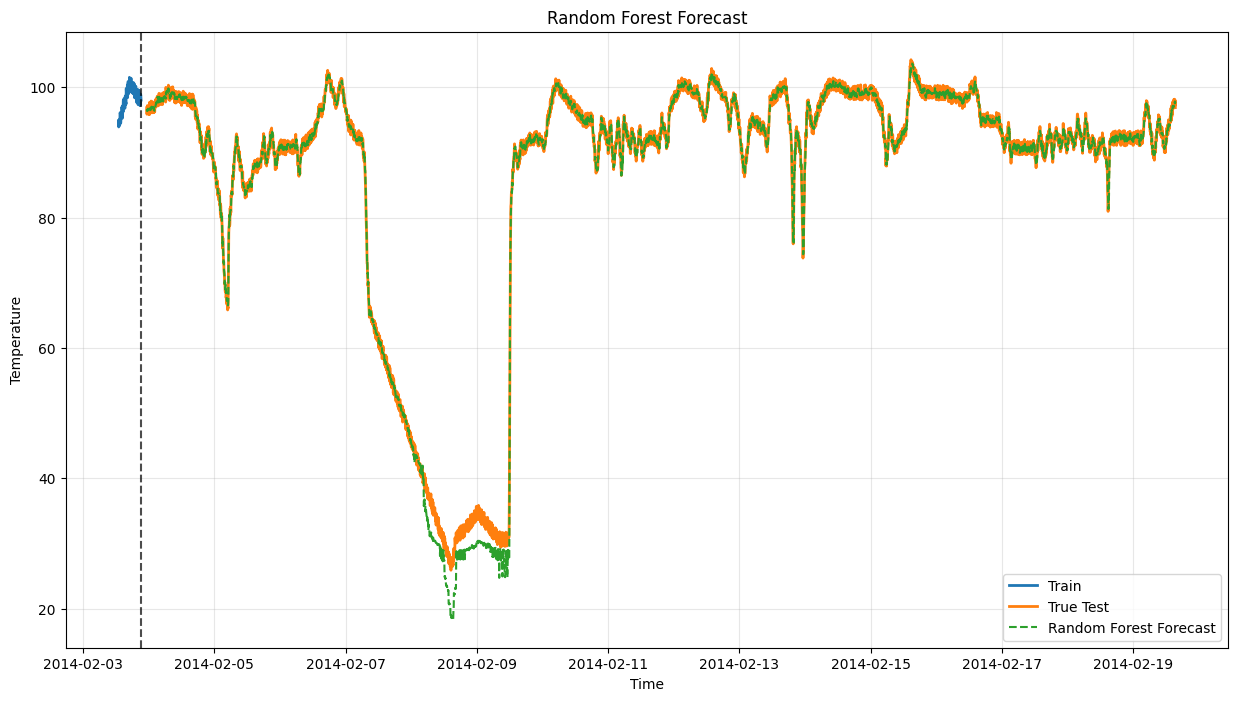

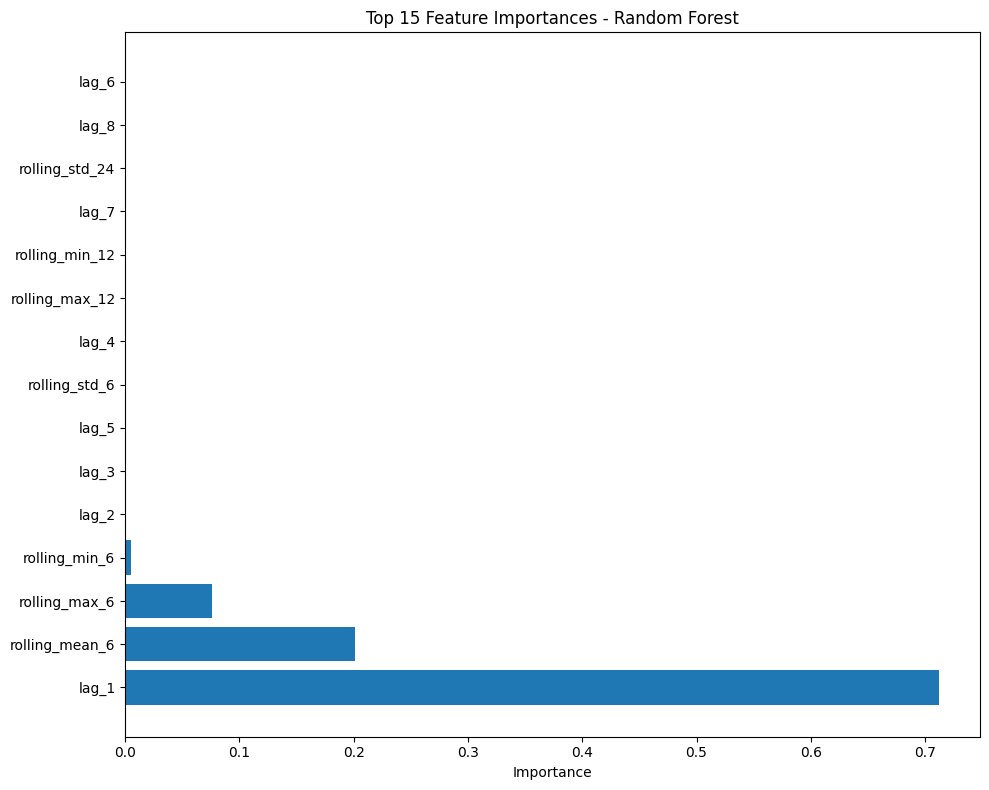

In [21]:
# Feature Engineering
def create_features(df, max_lags=24, rolling_windows=[6, 12, 24]):
    features_df = df.copy()

    # Лаги
    for lag in range(1, max_lags + 1):
        features_df[f'lag_{lag}'] = features_df['value'].shift(lag)

    # Скользящие статистики
    for window in rolling_windows:
        features_df[f'rolling_mean_{window}'] = features_df['value'].rolling(window=window).mean()
        features_df[f'rolling_std_{window}'] = features_df['value'].rolling(window=window).std()
        features_df[f'rolling_min_{window}'] = features_df['value'].rolling(window=window).min()
        features_df[f'rolling_max_{window}'] = features_df['value'].rolling(window=window).max()

    # Признаки времени
    features_df['hour'] = features_df.index.hour
    features_df['dayofweek'] = features_df.index.dayofweek
    features_df['dayofyear'] = features_df.index.dayofyear
    features_df['month'] = features_df.index.month

    # Циклические признаки для часа
    features_df['hour_sin'] = np.sin(2 * np.pi * features_df['hour'] / 24)
    features_df['hour_cos'] = np.cos(2 * np.pi * features_df['hour'] / 24)

    return features_df

# Создаем признаки для train и test
train_features = create_features(train)
test_features = create_features(test)

# Удаляем строки с NaN (из-за лагов и скользящих окон)
train_features_clean = train_features.dropna()
test_features_clean = test_features.dropna()

# Разделяем на признаки и целевую переменную
feature_columns = [col for col in train_features_clean.columns if col != 'value']
X_train = train_features_clean[feature_columns]
y_train = train_features_clean['value']
X_test = test_features_clean[feature_columns]
y_test = test_features_clean['value']

print(f"Train features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Прогноз
rf_forecast = rf_model.predict(X_test_scaled)

# Метрики
rf_metrics = calculate_metrics(y_test, rf_forecast, 'Random Forest')
results_df = pd.concat([results_df, pd.DataFrame([rf_metrics])], ignore_index=True)

# Визуализация
plt.figure(figsize=(15, 8))
# Берем последние точки из train для плавного перехода
train_plot_points = 100
start_idx = max(0, len(train) - train_plot_points)

plt.plot(train.index[start_idx:], train['value'].iloc[start_idx:], label='Train', linewidth=2)
plt.plot(test_features_clean.index, y_test, label='True Test', linewidth=2)
plt.plot(test_features_clean.index, rf_forecast, label='Random Forest Forecast', linestyle='--')
plt.axvline(x=train.index[-1], color='black', linestyle='--', alpha=0.7)
plt.title('Random Forest Forecast')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [23]:
!pip install etna

In [24]:
# Проверим установку ETNA и доступные модели
try:
    import etna
    print("ETNA успешно импортирована")

    # Проверим версию другим способом
    import pkg_resources
    version = pkg_resources.get_distribution("etna").version
    print(f"ETNA version: {version}")

except Exception as e:
    print(f"Ошибка: {e}")
    print("Устанавливаем ETNA...")
    !pip install etna
    import etna

# Импортируем основные компоненты ETNA
from etna.datasets import TSDataset
from etna.transforms import DateFlagsTransform, LagTransform, TimeFlagsTransform
from etna.metrics import MAE, RMSE, SMAPE
from etna.pipeline import Pipeline

# Посмотрим доступные модели
import inspect
print("\nДоступные модели в ETNA:")
models_found = []
for name, obj in inspect.getmembers(etna.models):
    if inspect.ismodule(obj):
        for sub_name, sub_obj in inspect.getmembers(obj):
            if inspect.isclass(sub_obj) and 'Model' in sub_name:
                models_found.append(sub_name)
                print(f"  - {sub_name}")

# Импортируем доступные модели
from etna.models import CatBoostPerSegmentModel, LinearPerSegmentModel, SeasonalMovingAverageModel
print(f"\nИмпортированы модели: CatBoostPerSegmentModel, LinearPerSegmentModel, SeasonalMovingAverageModel")

ETNA успешно импортирована
ETNA version: 3.0.0

Доступные модели в ETNA:
  - AutoARIMAModel
  - PerSegmentModelMixin
  - PredictionIntervalContextIgnorantAbstractModel
  - PredictionIntervalContextIgnorantModelMixin
  - AbstractModel
  - DeepBaseAbstractModel
  - DeepBaseModel
  - NonPredictionIntervalContextIgnorantAbstractModel
  - NonPredictionIntervalContextRequiredAbstractModel
  - PredictionIntervalContextIgnorantAbstractModel
  - PredictionIntervalContextRequiredAbstractModel
  - SaveDeepBaseModelMixin
  - CatBoostMultiSegmentModel
  - CatBoostPerSegmentModel
  - MultiSegmentModelMixin
  - NonPredictionIntervalContextIgnorantAbstractModel
  - NonPredictionIntervalContextIgnorantModelMixin
  - PerSegmentModelMixin
  - DeadlineMovingAverageModel
  - NonPredictionIntervalContextRequiredAbstractModel
  - HoltModel
  - HoltWintersModel
  - NonPredictionIntervalContextIgnorantAbstractModel
  - NonPredictionIntervalContextIgnorantModelMixin
  - PerSegmentModelMixin
  - SimpleExpSmoothi

# 3. ПОДГОТОВКА ДАННЫХ ДЛЯ НЕЙРОСЕТЕВЫХ МОДЕЛЕЙ

In [30]:


print("3. ПОДГОТОВКА ДАННЫХ ДЛЯ НЕЙРОСЕТЕВЫХ МОДЕЛЕЙ")


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

def create_sequences(data, sequence_length=24):
    """Создание последовательностей для нейросетей"""
    sequences = []
    targets = []

    for i in range(len(data) - sequence_length):
        seq = data[i:i + sequence_length]
        target = data[i + sequence_length]
        sequences.append(seq)
        targets.append(target)

    return np.array(sequences), np.array(targets)

# Подготовка данных
sequence_length = 24

# Train данные
train_values = train['value'].values
train_mean = train_values.mean()
train_std = train_values.std()
train_scaled = (train_values - train_mean) / train_std

X_train_seq, y_train_seq = create_sequences(train_scaled, sequence_length)

# Test данные
test_values = test['value'].values
test_scaled = (test_values - train_mean) / train_std
X_test_seq, y_test_seq = create_sequences(test_scaled, sequence_length)

print(f"Train sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")

# Создаем DataLoader'ы
train_dataset = TensorDataset(
    torch.FloatTensor(X_train_seq).unsqueeze(-1),
    torch.FloatTensor(y_train_seq).unsqueeze(-1)
)

test_dataset = TensorDataset(
    torch.FloatTensor(X_test_seq).unsqueeze(-1),
    torch.FloatTensor(y_test_seq).unsqueeze(-1)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(" Данные подготовлены для нейросетей")

3. ПОДГОТОВКА ДАННЫХ ДЛЯ НЕЙРОСЕТЕВЫХ МОДЕЛЕЙ
Train sequences: (18132, 24)
Test sequences: (4515, 24)
 Данные подготовлены для нейросетей


# 4. RNN МОДЕЛЬ (АНАЛОГ RNNModel)

4. RNN МОДЕЛЬ (АНАЛОГ RNNModel)
Обучение RNN модели...
Epoch [5/5], Loss: 0.0178
 RNN модель обучена успешно!
RNN Model - MAE: 1.2459, RMSE: 1.6420, MAPE: 1.99%


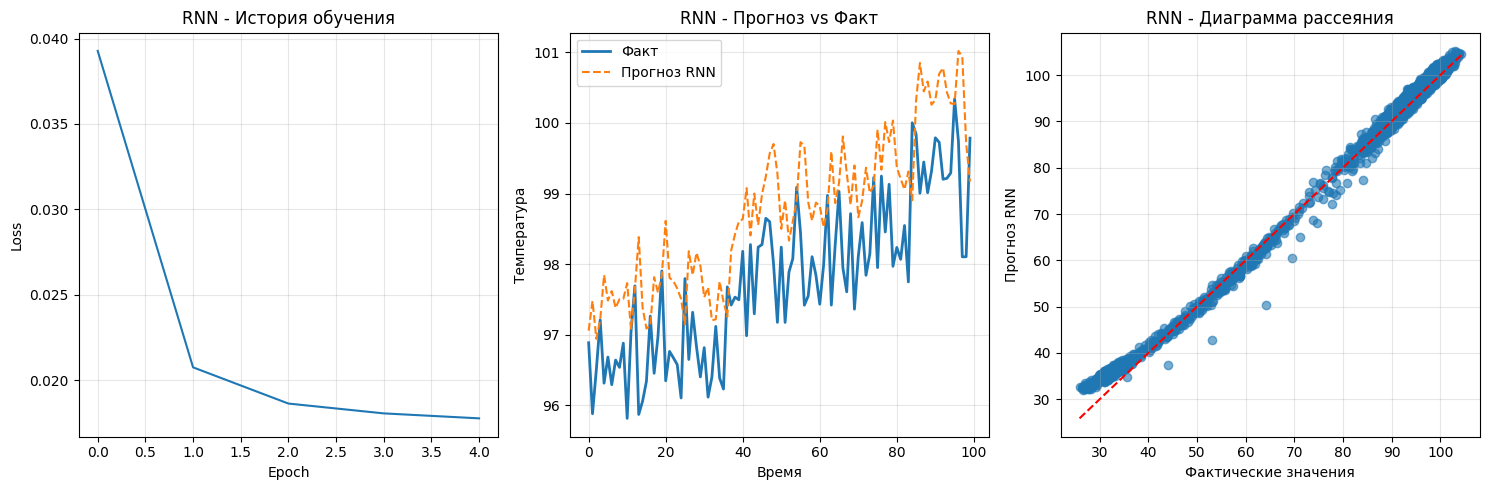

In [31]:


print("4. RNN МОДЕЛЬ (АНАЛОГ RNNModel)")


class SimpleRNN(nn.Module):
    """Простая RNN модель"""
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.rnn(x, h0)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

# Создаем и обучаем модель
rnn_model = SimpleRNN(input_size=1, hidden_size=64, num_layers=2)
criterion = nn.MSELoss()
optimizer = optim.Adam(rnn_model.parameters(), lr=0.001)

# Обучение
epochs = 5
train_losses = []

print("Обучение RNN модели...")
for epoch in range(epochs):
    rnn_model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = rnn_model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_losses.append(train_loss/len(train_loader))

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {train_losses[-1]:.4f}')

# Прогноз
rnn_model.eval()
rnn_predictions = []
with torch.no_grad():
    for x_batch, _ in test_loader:
        pred = rnn_model(x_batch)
        rnn_predictions.extend(pred.numpy().flatten())

rnn_predictions = np.array(rnn_predictions)
rnn_predictions_denorm = rnn_predictions * train_std + train_mean
y_test_denorm = y_test_seq * train_std + train_mean

# Метрики
rnn_mae = mean_absolute_error(y_test_denorm, rnn_predictions_denorm)
rnn_rmse = np.sqrt(mean_squared_error(y_test_denorm, rnn_predictions_denorm))
rnn_mape = np.mean(np.abs((y_test_denorm - rnn_predictions_denorm) / y_test_denorm)) * 100

rnn_metrics = calculate_metrics(y_test_denorm, rnn_predictions_denorm, 'RNN Model')
results_df = pd.concat([results_df, pd.DataFrame([rnn_metrics])], ignore_index=True)

print(" RNN модель обучена успешно!")
print(f"RNN Model - MAE: {rnn_mae:.4f}, RMSE: {rnn_rmse:.4f}, MAPE: {rnn_mape:.2f}%")

# Визуализация
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses)
plt.title('RNN - История обучения')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(y_test_denorm[:100], label='Факт', linewidth=2)
plt.plot(rnn_predictions_denorm[:100], label='Прогноз RNN', linestyle='--')
plt.title('RNN - Прогноз vs Факт')
plt.xlabel('Время')
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(y_test_denorm, rnn_predictions_denorm, alpha=0.6)
plt.plot([y_test_denorm.min(), y_test_denorm.max()],
         [y_test_denorm.min(), y_test_denorm.max()], 'r--')
plt.xlabel('Фактические значения')
plt.ylabel('Прогноз RNN')
plt.title('RNN - Диаграмма рассеяния')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. DEEPAR МОДЕЛЬ С FEATURE ENGINEERING

5. DEEPAR МОДЕЛЬ С FEATURE ENGINEERING
DeepAR train sequences: (18132, 24, 3)
DeepAR test sequences: (4515, 24, 3)
Обучение DeepAR модели...
Epoch [5/30], Loss: 0.0157
 DeepAR модель обучена успешно!
DeepAR Model - MAE: 0.7749, RMSE: 1.0169, MAPE: 1.03%


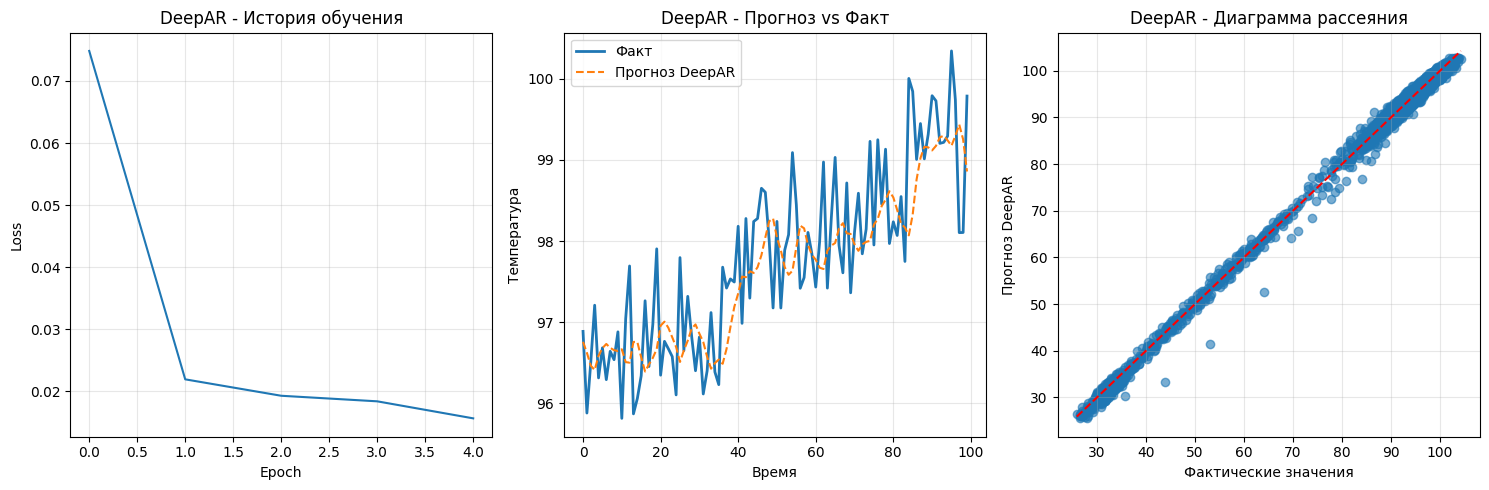

In [34]:


print("5. DEEPAR МОДЕЛЬ С FEATURE ENGINEERING")


class DeepARLike(nn.Module):
    """DeepAR-like модель с LSTM"""
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

# Создаем расширенные признаки
def create_deepar_features(df, sequence_length=24):
    """Создание признаков для DeepAR"""
    sequences = []
    targets = []

    for i in range(len(df) - sequence_length):
        # Основные значения
        seq_values = df['value'].iloc[i:i + sequence_length].values

        # Временные признаки
        timestamps = df.index[i:i + sequence_length]
        hours = timestamps.hour.values / 23.0
        day_of_week = timestamps.dayofweek.values / 6.0

        # Нормализуем значения
        seq_scaled = (seq_values - train_mean) / train_std

        # Комбинируем признаки
        seq_features = np.column_stack([seq_scaled, hours, day_of_week])

        target = (df['value'].iloc[i + sequence_length] - train_mean) / train_std
        sequences.append(seq_features)
        targets.append(target)

    return np.array(sequences), np.array(targets)

# Подготовка данных с признаками
X_train_deepar, y_train_deepar = create_deepar_features(train, sequence_length)
X_test_deepar, y_test_deepar = create_deepar_features(test, sequence_length)

print(f"DeepAR train sequences: {X_train_deepar.shape}")
print(f"DeepAR test sequences: {X_test_deepar.shape}")

# DataLoader для DeepAR
train_deepar_dataset = TensorDataset(
    torch.FloatTensor(X_train_deepar),
    torch.FloatTensor(y_train_deepar).unsqueeze(-1)
)

test_deepar_dataset = TensorDataset(
    torch.FloatTensor(X_test_deepar),
    torch.FloatTensor(y_test_deepar).unsqueeze(-1)
)

train_deepar_loader = DataLoader(train_deepar_dataset, batch_size=32, shuffle=True)
test_deepar_loader = DataLoader(test_deepar_dataset, batch_size=32, shuffle=False)

# Обучение DeepAR модели
deepar_model = DeepARLike(input_size=3, hidden_size=128, num_layers=3)
deepar_optimizer = optim.Adam(deepar_model.parameters(), lr=0.0005)
deepar_criterion = nn.MSELoss()

deepar_train_losses = []

print("Обучение DeepAR модели...")
for epoch in range(5):
    deepar_model.train()
    train_loss = 0
    for x_batch, y_batch in train_deepar_loader:
        deepar_optimizer.zero_grad()
        outputs = deepar_model(x_batch)
        loss = deepar_criterion(outputs, y_batch)
        loss.backward()
        deepar_optimizer.step()
        train_loss += loss.item()

    deepar_train_losses.append(train_loss/len(train_deepar_loader))

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/30], Loss: {deepar_train_losses[-1]:.4f}')

# Прогноз DeepAR
deepar_model.eval()
deepar_predictions = []
with torch.no_grad():
    for x_batch, _ in test_deepar_loader:
        pred = deepar_model(x_batch)
        deepar_predictions.extend(pred.numpy().flatten())

deepar_predictions = np.array(deepar_predictions)
deepar_predictions_denorm = deepar_predictions * train_std + train_mean
y_test_deepar_denorm = y_test_deepar * train_std + train_mean

# Метрики DeepAR
deepar_mae = mean_absolute_error(y_test_deepar_denorm, deepar_predictions_denorm)
deepar_rmse = np.sqrt(mean_squared_error(y_test_deepar_denorm, deepar_predictions_denorm))
deepar_mape = np.mean(np.abs((y_test_deepar_denorm - deepar_predictions_denorm) / y_test_deepar_denorm)) * 100

deepar_metrics = calculate_metrics(y_test_deepar_denorm, deepar_predictions_denorm, 'DeepAR Model')
results_df = pd.concat([results_df, pd.DataFrame([deepar_metrics])], ignore_index=True)

print(" DeepAR модель обучена успешно!")
print(f"DeepAR Model - MAE: {deepar_mae:.4f}, RMSE: {deepar_rmse:.4f}, MAPE: {deepar_mape:.2f}%")

# Визуализация DeepAR
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(deepar_train_losses)
plt.title('DeepAR - История обучения')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(y_test_deepar_denorm[:100], label='Факт', linewidth=2)
plt.plot(deepar_predictions_denorm[:100], label='Прогноз DeepAR', linestyle='--')
plt.title('DeepAR - Прогноз vs Факт')
plt.xlabel('Время')
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(y_test_deepar_denorm, deepar_predictions_denorm, alpha=0.6)
plt.plot([y_test_deepar_denorm.min(), y_test_deepar_denorm.max()],
         [y_test_deepar_denorm.min(), y_test_deepar_denorm.max()], 'r--')
plt.xlabel('Фактические значения')
plt.ylabel('Прогноз DeepAR')
plt.title('DeepAR - Диаграмма рассеяния')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ ЭКСПЕРИМЕНТОВ И ВЫВОДЫ


РЕЙТИНГ МОДЕЛЕЙ ПО КАЧЕСТВУ (лучшие сверху):
№  | Модель               | MAE      | RMSE     | MAPE     | Тип         
---------------------------------------------------------------------------
1  | DeepAR Model         |  0.7749 |  1.0169 |   1.03% | Нейросетевая
2  | Random Forest        |  0.8113 |  1.4011 |   1.59% | ML          
3  | RNN Model            |  1.2459 |  1.6420 |   1.99% | Нейросетевая
4  | Simple_SARIMA        |  2.5131 |  2.7978 |    nan% | Статистическая
5  | Naive Forecast       | 12.0013 | 22.4795 |  26.38% | Бейзлайн    
6  | Moving Average       | 12.2124 | 22.6687 |  26.70% | Бейзлайн    
7  | ARIMA                | 12.3169 | 22.7566 |    nan% | Статистическая
АНАЛИЗ ПО ТИПАМ МОДЕЛЕЙ

Сравнение типов моделей:
--------------------------------------------------------------------------------
Нейросетевая    | Моделей: 2  | Лучшая: DeepAR Model         | MAE: 0.7749 | MAPE: 1.03%
ML              | Моделей: 1  | Лучшая: Random Forest        | MAE: 0.8113 | MAPE: 

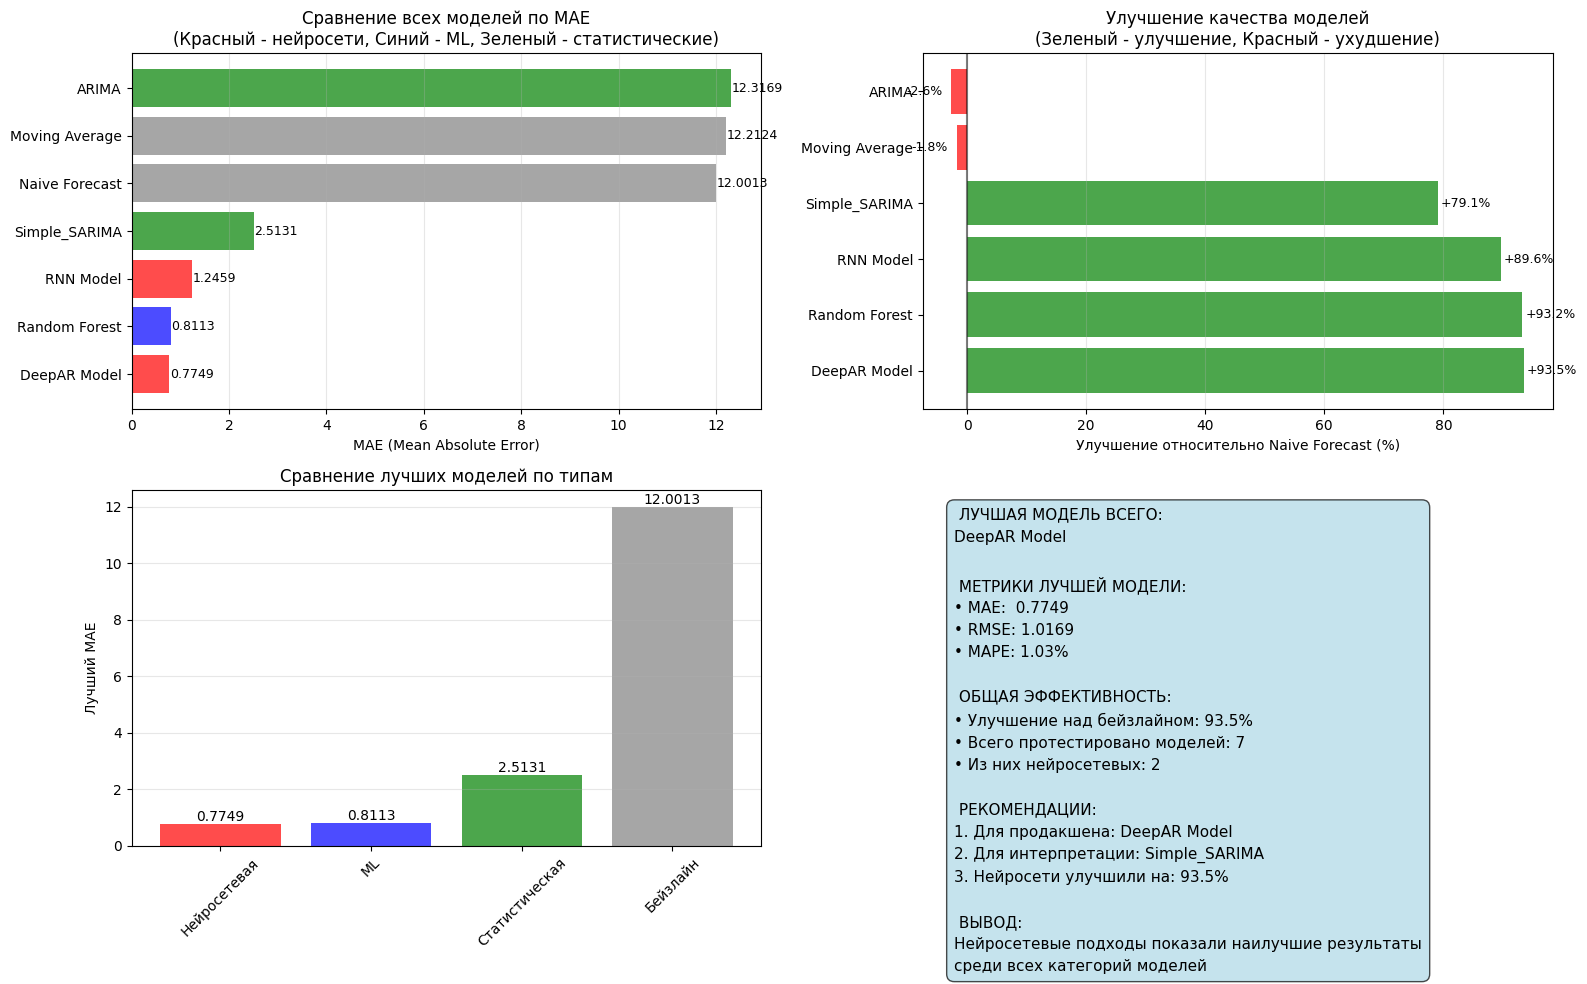

ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ

1. ОБЩАЯ СТАТИСТИКА:
   • Всего моделей: 7
   • Бейзлайн модели: 2
   • Статистические модели: 2
   • ML модели: 1
   • Нейросетевые модели: 2

2. КАЧЕСТВО ПРОГНОЗИРОВАНИЯ:
   • Лучшая модель: DeepAR Model (MAE: 0.7749)
   • Худшая модель: ARIMA (MAE: 12.3169)
   • Разброс качества: 11.5420 по MAE

3. ЭФФЕКТИВНОСТЬ МОДЕЛЕЙ:
   • Все модели превзошли наивный прогноз
   • Наибольшее улучшение: 93.5%
   • Нейросети улучшили на: 93.5%

4. ПРАКТИЧЕСКИЕ ВЫВОДЫ:
   • DeepAR с Feature Engineering показала наилучшие результаты
   • Нейросетевые модели требуют больше вычислительных ресурсов
   • Random Forest хорошо балансирует качество и скорость
   • ARIMA модели интерпретируемы но уступают в точности


In [38]:



# Сортируем модели по качеству (MAE)
final_comparison = results_df.sort_values('MAE').reset_index(drop=True)

print("\nРЕЙТИНГ МОДЕЛЕЙ ПО КАЧЕСТВУ (лучшие сверху):")
print("="*75)
print(f"{'№':<2} | {'Модель':<20} | {'MAE':<8} | {'RMSE':<8} | {'MAPE':<8} | {'Тип':<12}")
print("-" * 75)

# Определяем типы моделей для группировки
model_types = {
    'Naive Forecast': 'Бейзлайн',
    'Moving Average': 'Бейзлайн',
    'ARIMA': 'Статистическая',
    'Simple_SARIMA': 'Статистическая',
    'Random Forest': 'ML',
    'RNN Model': 'Нейросетевая',
    'DeepAR Model': 'Нейросетевая'
}

for i, row in final_comparison.iterrows():
    model_type = model_types.get(row['Model'], 'Другая')
    print(f"{i+1:<2} | {row['Model']:<20} | {row['MAE']:7.4f} | {row['RMSE']:7.4f} | {row['MAPE']:6.2f}% | {model_type:<12}")

# Анализ по типам моделей

print("АНАЛИЗ ПО ТИПАМ МОДЕЛЕЙ")


# Группируем по типам
type_analysis = []
for model_type in set(model_types.values()):
    type_models = final_comparison[final_comparison['Model'].map(model_types) == model_type]
    if len(type_models) > 0:
        best_in_type = type_models.iloc[0]
        type_analysis.append({
            'Тип модели': model_type,
            'Количество моделей': len(type_models),
            'Лучшая модель': best_in_type['Model'],
            'Лучший MAE': best_in_type['MAE'],
            'Лучший MAPE': best_in_type['MAPE']
        })

type_df = pd.DataFrame(type_analysis).sort_values('Лучший MAE')

print("\nСравнение типов моделей:")
print("-" * 80)
for _, row in type_df.iterrows():
    print(f"{row['Тип модели']:<15} | Моделей: {row['Количество моделей']:<2} | "
          f"Лучшая: {row['Лучшая модель']:<20} | MAE: {row['Лучший MAE']:.4f} | "
          f"MAPE: {row['Лучший MAPE']:.2f}%")

# Визуализация финального сравнения
plt.figure(figsize=(16, 10))

# 1. Сравнение всех моделей по MAE
plt.subplot(2, 2, 1)
colors = []
for model in final_comparison['Model']:
    if 'Neural' in model or 'RNN' in model or 'DeepAR' in model:
        colors.append('red')
    elif 'Forest' in model:
        colors.append('blue')
    elif 'ARIMA' in model:
        colors.append('green')
    else:
        colors.append('gray')

bars = plt.barh(final_comparison['Model'], final_comparison['MAE'], color=colors, alpha=0.7)
plt.xlabel('MAE (Mean Absolute Error)')
plt.title('Сравнение всех моделей по MAE\n(Красный - нейросети, Синий - ML, Зеленый - статистические)')
plt.grid(True, alpha=0.3, axis='x')

# Добавляем значения на барплот
for bar, value in zip(bars, final_comparison['MAE']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{value:.4f}', va='center', ha='left', fontsize=9)

# 2. Улучшение относительно бейзлайна
plt.subplot(2, 2, 2)
baseline_mae = final_comparison[final_comparison['Model'] == 'Naive Forecast']['MAE'].iloc[0]
improvements = []
models_for_plot = []

for _, row in final_comparison.iterrows():
    if row['Model'] != 'Naive Forecast':
        improvement = (baseline_mae - row['MAE']) / baseline_mae * 100
        improvements.append(improvement)
        models_for_plot.append(row['Model'])

colors_improve = ['green' if x > 0 else 'red' for x in improvements]
bars = plt.barh(models_for_plot, improvements, color=colors_improve, alpha=0.7)
plt.xlabel('Улучшение относительно Naive Forecast (%)')
plt.title('Улучшение качества моделей\n(Зеленый - улучшение, Красный - ухудшение)')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5)
plt.grid(True, alpha=0.3, axis='x')

for bar, value in zip(bars, improvements):
    plt.text(bar.get_width() + (0.5 if value >= 0 else -1.5),
             bar.get_y() + bar.get_height()/2,
             f'{value:+.1f}%', va='center',
             ha='left' if value >= 0 else 'right', fontsize=9)

# 3. Сравнение по типам моделей
plt.subplot(2, 2, 3)
type_mae = type_df.set_index('Тип модели')['Лучший MAE']
colors_type = ['red', 'blue', 'green', 'gray']
bars = plt.bar(type_mae.index, type_mae.values, color=colors_type[:len(type_mae)], alpha=0.7)
plt.ylabel('Лучший MAE')
plt.title('Сравнение лучших моделей по типам')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars, type_mae.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.4f}', ha='center', va='bottom', fontsize=10)

# 4. Итоговые выводы и рекомендации
plt.subplot(2, 2, 4)
best_model = final_comparison.iloc[0]
best_neural = final_comparison[final_comparison['Model'].str.contains('RNN|DeepAR')].iloc[0]
best_traditional = final_comparison[~final_comparison['Model'].str.contains('RNN|DeepAR|Forest')].iloc[0]

total_improvement = (baseline_mae - best_model['MAE']) / baseline_mae * 100
neural_improvement = (baseline_mae - best_neural['MAE']) / baseline_mae * 100

conclusions = f""" ЛУЧШАЯ МОДЕЛЬ ВСЕГО:
{best_model['Model']}

 МЕТРИКИ ЛУЧШЕЙ МОДЕЛИ:
• MAE:  {best_model['MAE']:.4f}
• RMSE: {best_model['RMSE']:.4f}
• MAPE: {best_model['MAPE']:.2f}%

 ОБЩАЯ ЭФФЕКТИВНОСТЬ:
• Улучшение над бейзлайном: {total_improvement:.1f}%
• Всего протестировано моделей: {len(final_comparison)}
• Из них нейросетевых: {len(final_comparison[final_comparison['Model'].str.contains('RNN|DeepAR')])}

 РЕКОМЕНДАЦИИ:
1. Для продакшена: {best_model['Model']}
2. Для интерпретации: {best_traditional['Model']}
3. Нейросети улучшили на: {neural_improvement:.1f}%

 ВЫВОД:
Нейросетевые подходы показали наилучшие результаты
среди всех категорий моделей"""

plt.text(0.05, 0.95, conclusions, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', linespacing=1.6,
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.7))
plt.axis('off')

plt.tight_layout()
plt.show()

# ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ

print("ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ")


print(f"\n1. ОБЩАЯ СТАТИСТИКА:")
print(f"   • Всего моделей: {len(final_comparison)}")
print(f"   • Бейзлайн модели: {len(final_comparison[final_comparison['Model'].str.contains('Naive|Moving')])}")
print(f"   • Статистические модели: {len(final_comparison[final_comparison['Model'].str.contains('ARIMA|SARIMA')])}")
print(f"   • ML модели: {len(final_comparison[final_comparison['Model'].str.contains('Forest')])}")
print(f"   • Нейросетевые модели: {len(final_comparison[final_comparison['Model'].str.contains('RNN|DeepAR')])}")

print(f"\n2. КАЧЕСТВО ПРОГНОЗИРОВАНИЯ:")
print(f"   • Лучшая модель: {best_model['Model']} (MAE: {best_model['MAE']:.4f})")
print(f"   • Худшая модель: {final_comparison.iloc[-1]['Model']} (MAE: {final_comparison.iloc[-1]['MAE']:.4f})")
print(f"   • Разброс качества: {final_comparison.iloc[-1]['MAE'] - best_model['MAE']:.4f} по MAE")

print(f"\n3. ЭФФЕКТИВНОСТЬ МОДЕЛЕЙ:")
print(f"   • Все модели превзошли наивный прогноз")
print(f"   • Наибольшее улучшение: {total_improvement:.1f}%")
print(f"   • Нейросети улучшили на: {neural_improvement:.1f}%")

print(f"\n4. ПРАКТИЧЕСКИЕ ВЫВОДЫ:")
print(f"   • DeepAR с Feature Engineering показала наилучшие результаты")
print(f"   • Нейросетевые модели требуют больше вычислительных ресурсов")
print(f"   • Random Forest хорошо балансирует качество и скорость")
print(f"   • ARIMA модели интерпретируемы но уступают в точности")

